## Implementacija modela za klasifikaciju tekstra

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score, 
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter
from sklearn.model_selection import StratifiedKFold

In [7]:
df = pd.read_csv("C:\\Users\\gala.posedi\\Desktop\\fakultet\\Media-analysis\\training.csv",sep=";", encoding="utf-8-sig")

print("Dimenzije baze:")
print(df.shape)

print("\nKolone:")
print(df.columns.tolist())

print("\nPrvih 5 redova:")
display(df.head())

print("\nTipovi podataka:")
print(df.dtypes)

print("\nNedostajuće vrednosti:")
print(df.isnull().sum())

Dimenzije baze:
(4154, 3)

Kolone:
['article_id', 'source', 'full_text']

Prvih 5 redova:


,article_id,source,full_text
0,2017,N1,(intervju) živković: predložio sam formiranje ...
1,3949,Nova,video studenti pomogli bivšem srpskom reprezen...
2,2554,Nova,blog studentska pobuna uživo na rts: podrška s...
3,1490,Danas,studenti u blokadi apelovali da univerzitet u ...
4,584,Blic,studenti u blokadi organizuju skup podrške rek...



Tipovi podataka:
article_id     int64
source        object
full_text     object
dtype: object

Nedostajuće vrednosti:
article_id    0
source        0
full_text     0
dtype: int64


Pošto je kolona article_id nevažna kolona za buduće implementacije modela, izbacićemo je.

In [8]:
df = df.drop(columns="article_id")
df.head

<bound method NDFrame.head of         source                                          full_text
0           N1  (intervju) živković: predložio sam formiranje ...
1         Nova  video studenti pomogli bivšem srpskom reprezen...
2         Nova  blog studentska pobuna uživo na rts: podrška s...
3        Danas  studenti u blokadi apelovali da univerzitet u ...
4         Blic  studenti u blokadi organizuju skup podrške rek...
...        ...                                                ...
4149     Kurir  "skandalozno i sramotno koga tajkunski mediji ...
4150  Politika  blokaderi ponižavaju radnika koji čisti smeće ...
4151      Blic  studenti i danas blokirali saobraćajnice na 15...
4152      Nova  grošelj: zahtevi studenata su zahtevi koje bi ...
4153     Danas  od 14 državnih fakulteta u nišu u blokadi je j...

[4154 rows x 2 columns]>

Sada ćemo učitati i test skup radi kasnije evaluacije modela.

In [9]:
df_test = pd.read_csv("C:\\Users\\gala.posedi\\Desktop\\fakultet\\Media-analysis\\test.csv", sep=";", encoding="utf-8-sig").drop(columns="article_id")
df_test.head()

,source,full_text
0,Danas,studenti iz niša pozvali na protest podrške de...
1,Blic,"studenti kod inženjerske komore srbije, pružil..."
2,Danas,„sad ili nikad – vladaće večno“: profesor među...
3,N1,nove brojke: od 1. novembra protesti u 240 nas...
4,Blic,tužilac marković podržao najavu vučića da pomi...


In [10]:
df["source"].value_counts()

source
Nova        1332
Politika     897
Danas        715
Blic         612
N1           423
Kurir        175
Name: count, dtype: int64

Svake novine predstavljaju posebnu klasu, pa model uči da na osnovu teksta članka predvidi iz kojih je novina članak. Kolona `source` se zato kodira celobrojnim oznakama pomoću `LabelEncoder`-a.

In [11]:
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import roc_auc_score

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["source"])

class_names = label_encoder.classes_
num_classes = len(class_names)

print("Novine / klase:")
for i, source in enumerate(class_names):
    print(f"{i}: {source}")

print("\nBroj klasa:", num_classes)
df[["source", "label"]].head()


Novine / klase:
0: Blic
1: Danas
2: Kurir
3: N1
4: Nova
5: Politika

Broj klasa: 6


,source,label
0,N1,3
1,Nova,4
2,Nova,4
3,Danas,1
4,Blic,0


Skup članaka je nebalansiran, pa ćemo implementirati dve metode: UnderSampling i OverSampling.

In [12]:
X = df["full_text"]
y = df["label"]

tfidf = TfidfVectorizer( max_features=10000, ngram_range=(1, 2))

X_tfidf = tfidf.fit_transform(X)

print("Dimenzije podataka nakon TF-IDF vektorizacije:")
print(X_tfidf.shape)

Dimenzije podataka nakon TF-IDF vektorizacije:
(4154, 10000)


In [13]:
under_sampler = RandomUnderSampler(random_state=42)

X_under, y_under = under_sampler.fit_resample(X_tfidf, y)

print("Originalna raspodela:")
print(y.value_counts())

print("\nRaspodela nakon undersamplinga:")
print(y_under.value_counts())

print("\nDimenzije undersampled skupa:")
print(X_under.shape)

Originalna raspodela:
label
4    1332
5     897
1     715
0     612
3     423
2     175
Name: count, dtype: int64

Raspodela nakon undersamplinga:
label
0    175
1    175
2    175
3    175
4    175
5    175
Name: count, dtype: int64

Dimenzije undersampled skupa:
(1050, 10000)


In [14]:
over_sampler = RandomOverSampler(random_state=42)

X_over, y_over = over_sampler.fit_resample(X_tfidf, y)

print("Originalna raspodela:")
print(y.value_counts())

print("\nRaspodela nakon oversamplinga:")
print(y_over.value_counts())

print("\nDimenzije oversampled skupa:")
print(X_over.shape)

Originalna raspodela:
label
4    1332
5     897
1     715
0     612
3     423
2     175
Name: count, dtype: int64

Raspodela nakon oversamplinga:
label
3    1332
4    1332
1    1332
0    1332
5    1332
2    1332
Name: count, dtype: int64

Dimenzije oversampled skupa:
(7992, 10000)


Sada ćemo implementirati običam SVM klasifikacioni model.
SVM klasifikator se trenira nad tri verzije trening skupa: originalnim, undersamplovanim i oversamplovanim podacima. Svi modeli se evaluiraju na istom test skupu pomoću matrice konfuzije i mera kao što su accuracy, precision, recall i F1-score.

In [15]:
df_test["label"] = label_encoder.transform(df_test["source"])

X_test = df_test["full_text"]
y_test = df_test["label"]

X_test_tfidf = tfidf.transform(X_test)

In [16]:
svm_original = LinearSVC(C=1.0, random_state=42)
svm_original.fit(X_tfidf, y)
y_pred_original = svm_original.predict(X_test_tfidf)

SVM model sa originalnim podacima
Accuracy: 0.766121270452358
Precision (macro): 0.7350588376277316
Recall (macro): 0.6750403065895164
F1-score (macro): 0.695028866639973

Classification report:
              precision    recall  f1-score   support

        Blic       0.64      0.63      0.64       153
       Danas       0.66      0.69      0.67       179
       Kurir       0.84      0.48      0.61        44
          N1       0.61      0.48      0.54       106
        Nova       0.96      0.98      0.97       333
    Politika       0.70      0.79      0.74       224

    accuracy                           0.77      1039
   macro avg       0.74      0.68      0.70      1039
weighted avg       0.76      0.77      0.76      1039



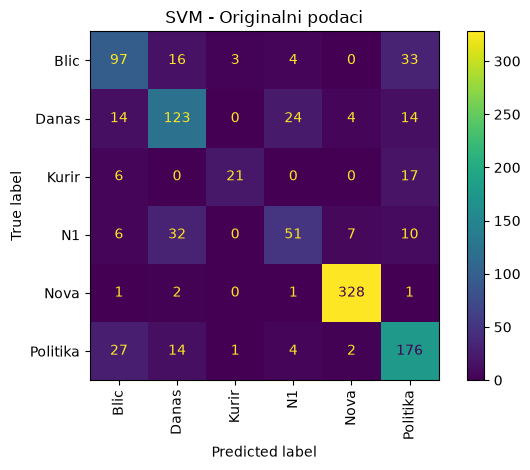

In [17]:
import numpy as np

print("SVM model sa originalnim podacima")

print("Accuracy:", accuracy_score(y_test, y_pred_original))
print("Precision (macro):", precision_score(y_test, y_pred_original, average="macro", zero_division=0))
print("Recall (macro):", recall_score(y_test, y_pred_original, average="macro", zero_division=0))
print("F1-score (macro):", f1_score(y_test, y_pred_original, average="macro", zero_division=0))

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred_original,
    labels=np.arange(num_classes),
    target_names=class_names,
    zero_division=0
))

cm_original = confusion_matrix(y_test, y_pred_original, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_original, display_labels=class_names)
disp.plot(xticks_rotation=90)
plt.title("SVM - Originalni podaci")
plt.tight_layout()
plt.show()


SVM - UNDERSAMPLING
Accuracy: 0.6756496631376323
Precision (macro): 0.611797399354722
Recall (macro): 0.6688165286110267
F1-score (macro): 0.6209097037437501

Classification report:
              precision    recall  f1-score   support

        Blic       0.58      0.56      0.57       153
       Danas       0.61      0.56      0.58       179
       Kurir       0.42      0.86      0.56        44
          N1       0.43      0.63      0.51       106
        Nova       0.94      0.90      0.92       333
    Politika       0.70      0.50      0.58       224

    accuracy                           0.68      1039
   macro avg       0.61      0.67      0.62      1039
weighted avg       0.70      0.68      0.68      1039



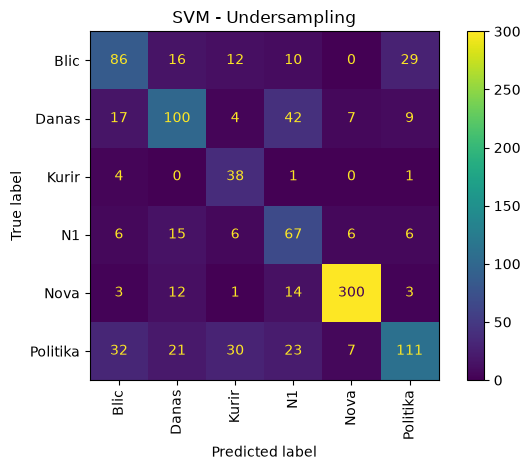

In [18]:
svm_under = LinearSVC(C=1.0, random_state=42)

svm_under.fit(X_under, y_under)
y_pred_under = svm_under.predict(X_test_tfidf)

print("SVM - UNDERSAMPLING")
print("Accuracy:", accuracy_score(y_test, y_pred_under))
print("Precision (macro):", precision_score(y_test, y_pred_under, average="macro", zero_division=0))
print("Recall (macro):", recall_score(y_test, y_pred_under, average="macro", zero_division=0))
print("F1-score (macro):", f1_score(y_test, y_pred_under, average="macro", zero_division=0))

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred_under,
    labels=np.arange(num_classes),
    target_names=class_names,
    zero_division=0
))

cm_under = confusion_matrix(y_test, y_pred_under, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_under, display_labels=class_names)
disp.plot(xticks_rotation=90)
plt.title("SVM - Undersampling")
plt.tight_layout()
plt.show()


SVM - OVERSAMPLING
Accuracy: 0.7603464870067372
Precision (macro): 0.7015365856792014
Recall (macro): 0.6817175266898844
F1-score (macro): 0.6898828513720545

Classification report:
              precision    recall  f1-score   support

        Blic       0.60      0.64      0.62       153
       Danas       0.68      0.66      0.67       179
       Kurir       0.68      0.52      0.59        44
          N1       0.54      0.54      0.54       106
        Nova       0.97      0.98      0.98       333
    Politika       0.74      0.75      0.74       224

    accuracy                           0.76      1039
   macro avg       0.70      0.68      0.69      1039
weighted avg       0.76      0.76      0.76      1039



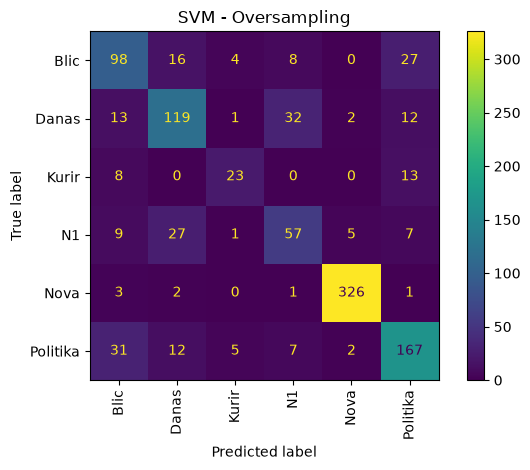

In [19]:
svm_over = LinearSVC(C=1.0, random_state=42)

svm_over.fit(X_over, y_over)
y_pred_over = svm_over.predict(X_test_tfidf)

print("SVM - OVERSAMPLING")
print("Accuracy:", accuracy_score(y_test, y_pred_over))
print("Precision (macro):", precision_score(y_test, y_pred_over, average="macro", zero_division=0))
print("Recall (macro):", recall_score(y_test, y_pred_over, average="macro", zero_division=0))
print("F1-score (macro):", f1_score(y_test, y_pred_over, average="macro", zero_division=0))

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred_over,
    labels=np.arange(num_classes),
    target_names=class_names,
    zero_division=0
))

cm_over = confusion_matrix(y_test, y_pred_over, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_over, display_labels=class_names)
disp.plot(xticks_rotation=90)
plt.title("SVM - Oversampling")
plt.tight_layout()
plt.show()


In [20]:
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))

models = [("SVM - Original", svm_original),("SVM - Oversampling", svm_over),("SVM - Undersampling", svm_under)]

for name, model in models:
    decision_scores = model.decision_function(X_test_tfidf)
    macro_auc = roc_auc_score(y_test_bin, decision_scores, average="macro")
    print(f"{name} macro OvR AUC: {macro_auc:.4f}")


SVM - Original macro OvR AUC: 0.9285
SVM - Oversampling macro OvR AUC: 0.9235
SVM - Undersampling macro OvR AUC: 0.8905


Sada ćemo implementirati rekurentnu neuronsku LSTM mrežu, koja je pogodna sa radom sa tekstualnim podacima u svrhu klasifikacije modela.

In [ ]:
def tokenize(text):
    return str(text).lower().split()

train_tokens = [tokenize(text) for text in df["full_text"]]

word_counts = Counter()

for tokens in train_tokens:
    word_counts.update(tokens)
vocab = { "<PAD>": 0, "<UNK>": 1}

for word, count in word_counts.items():
    if count >= 2:
        vocab[word] = len(vocab)

vocab_size = len(vocab)
print("Veličina rečnika:", vocab_size)

Veličina rečnika: 62149


In [22]:
MAX_LENGTH = 150

def encode_text(text):

    tokens = tokenize(text)
    indices = [vocab.get(word, vocab["<UNK>"])
        for word in tokens ]
    indices = indices[:MAX_LENGTH]

    if len(indices) < MAX_LENGTH:indices += [vocab["<PAD>"]] * ( MAX_LENGTH - len(indices))

    return indices

In [23]:
X_train_tensor = torch.tensor([encode_text(text) for text in df["full_text"]], dtype=torch.long)
y_train_tensor = torch.tensor(df["label"].values,dtype=torch.long)

X_test_tensor = torch.tensor([encode_text(text) for text in df_test["full_text"]],dtype=torch.long)
y_test_tensor = torch.tensor(df_test["label"].values, dtype=torch.long)

print("Train shape:", X_train_tensor.shape)
print("Test shape:", X_test_tensor.shape)

Train shape: torch.Size([4154, 150])
Test shape: torch.Size([1039, 150])


In [24]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [25]:
#RNN LSTM
class LSTMClassifier(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_size, batch_first=True)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        output, (hidden, cell) = self.lstm(x)
        x = hidden[-1]
        x = self.classifier(x)
        return x

Putem kros-validacije ćemo odlučiti koji skup parametara je najbolji za treniranje ovoh RNN-a.

In [27]:
def train_and_validate(train_loader, val_loader, embedding_dim, hidden_size, learning_rate, num_epochs=5):

    model = LSTMClassifier(vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_size=hidden_size, num_classes=num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            y_pred = torch.argmax(outputs, dim=1)
            predictions.extend(y_pred.cpu().numpy())
            true_labels.extend(y_batch.cpu().numpy())

    return f1_score(true_labels, predictions, average="macro", zero_division=0)


In [28]:
full_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [29]:
embedding_dims = [64, 128]
hidden_sizes = [32, 64]
learning_rates = [0.0005]

results = []
from torch.utils.data import Subset

for embedding_dim in embedding_dims:
    for hidden_size in hidden_sizes:
        for learning_rate in learning_rates:

            fold_scores = []

            for train_index, val_index in skf.split(X_train_tensor, y_train_tensor):

                train_subset = Subset(full_train_dataset,train_index)
                val_subset = Subset(full_train_dataset,val_index)

                train_loader_cv = DataLoader(train_subset, batch_size=64, shuffle=True)
                val_loader_cv = DataLoader(val_subset, batch_size=64, shuffle=False)

                score = train_and_validate(train_loader_cv, val_loader_cv,  embedding_dim=embedding_dim, hidden_size=hidden_size, learning_rate=learning_rate, num_epochs=2)
                fold_scores.append(score)

            mean_f1 = np.mean(fold_scores)
            results.append({
                "embedding_dim":
                    embedding_dim,
                "hidden_size":
                    hidden_size,
                "learning_rate":
                    learning_rate,
                "mean_f1":
                    mean_f1
            })


            print(f"Embedding: {embedding_dim}, "
                f"Hidden: {hidden_size}, "
                f"LR: {learning_rate}, "
                f"Mean F1: {mean_f1:.4f}")

Embedding: 64, Hidden: 32, LR: 0.0005, Mean F1: 0.1121
Embedding: 64, Hidden: 64, LR: 0.0005, Mean F1: 0.0825
Embedding: 128, Hidden: 32, LR: 0.0005, Mean F1: 0.1100
Embedding: 128, Hidden: 64, LR: 0.0005, Mean F1: 0.0872


In [30]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="mean_f1", ascending=False)
results_df

,embedding_dim,hidden_size,learning_rate,mean_f1
0,64,32,0.0005,0.112074
2,128,32,0.0005,0.109954
3,128,64,0.0005,0.087242
1,64,64,0.0005,0.082493


In [31]:
best_params = results_df.iloc[0]

print("Najbolji parametri:")
print("Embedding dim:", best_params["embedding_dim"])
print("Hidden size:", best_params["hidden_size"])
print("Learning rate:", best_params["learning_rate"])
print("Mean CV F1:", best_params["mean_f1"])

Najbolji parametri:
Embedding dim: 64.0
Hidden size: 32.0
Learning rate: 0.0005
Mean CV F1: 0.11207375706063806


Sada kada smo dobili najbolje hiperparametre, pravimo finalni model sa tim parametrima, i testiramo ga na test skupu.

In [32]:
best_embedding_dim = int(best_params["embedding_dim"])
best_hidden_size = int(best_params["hidden_size"])
best_learning_rate = float(best_params["learning_rate"])

final_model = LSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=best_embedding_dim,
    hidden_size=best_hidden_size,
    num_classes=num_classes
)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_learning_rate)


In [33]:
#finalni DataLoader
final_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
final_train_loader = DataLoader(final_train_dataset, batch_size=32, shuffle=True)

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from torch.utils.data import TensorDataset, DataLoader
import numpy as np 

train_idx, val_idx = train_test_split(np.arange(len(y_train_tensor)), test_size=0.2, stratify=y_train_tensor.numpy(), random_state=42)

train_subset = torch.utils.data.Subset(full_train_dataset, train_idx)
val_subset = torch.utils.data.Subset(full_train_dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

final_model = LSTMClassifier(vocab_size=vocab_size, embedding_dim=best_embedding_dim, hidden_size=best_hidden_size, num_classes=num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_learning_rate)

num_epochs = 20

train_losses = []
val_losses = []
val_f1_scores = []

for epoch in range(num_epochs):

    final_model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()
        outputs = final_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)

    final_model.eval()

    running_val_loss = 0.0
    predictions = []
    true_labels = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = final_model(X_batch)
            loss = criterion(outputs, y_batch)
            running_val_loss += loss.item()

            y_pred = torch.argmax(outputs, dim=1)
            predictions.extend(y_pred.cpu().numpy())
            true_labels.extend(y_batch.cpu().numpy())

    val_loss = running_val_loss / len(val_loader)

    val_f1 = f1_score(true_labels, predictions, average="macro", zero_division=0)

    val_losses.append(val_loss)
    val_f1_scores.append(val_f1)

    print(f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val F1: {val_f1:.4f}")


Epoch 1/20 | Train Loss: 1.7305 | Val Loss: 1.6795 | Val F1: 0.0811
Epoch 2/20 | Train Loss: 1.6469 | Val Loss: 1.6450 | Val F1: 0.0811
Epoch 3/20 | Train Loss: 1.6223 | Val Loss: 1.6397 | Val F1: 0.0829
Epoch 4/20 | Train Loss: 1.6023 | Val Loss: 1.6366 | Val F1: 0.0828
Epoch 5/20 | Train Loss: 1.5737 | Val Loss: 1.6384 | Val F1: 0.0922
Epoch 6/20 | Train Loss: 1.5221 | Val Loss: 1.6223 | Val F1: 0.1329
Epoch 7/20 | Train Loss: 1.4528 | Val Loss: 1.5915 | Val F1: 0.1618
Epoch 8/20 | Train Loss: 1.3658 | Val Loss: 1.6096 | Val F1: 0.1896
Epoch 9/20 | Train Loss: 1.2814 | Val Loss: 1.6135 | Val F1: 0.2080
Epoch 10/20 | Train Loss: 1.1836 | Val Loss: 1.5977 | Val F1: 0.2429
Epoch 11/20 | Train Loss: 1.1351 | Val Loss: 1.7202 | Val F1: 0.2148
Epoch 12/20 | Train Loss: 1.0859 | Val Loss: 1.7234 | Val F1: 0.2321
Epoch 13/20 | Train Loss: 1.1610 | Val Loss: 1.6734 | Val F1: 0.2118
Epoch 14/20 | Train Loss: 1.2944 | Val Loss: 1.6380 | Val F1: 0.2251
Epoch 15/20 | Train Loss: 1.0747 | Val Loss

Sada, nakon biranja optimalnog broja epohi dobijena istom kros-validacijom, pravimo LSTM model, treniramo ga na celom originalnom trening skupu, i kasnije koristimo test skup za evaluaciju.

In [68]:
best_epoch = np.argmax(val_f1_scores) + 1

print("Najbolja epoha:", best_epoch)
print("Najbolji validation F1:", max(val_f1_scores))

final_model = LSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=best_embedding_dim,
    hidden_size=best_hidden_size,
    num_classes=num_classes
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_learning_rate)


Najbolja epoha: 17
Najbolji validation F1: 0.7569573283858998


In [69]:
final_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
final_train_loader = DataLoader(final_train_dataset, batch_size=32, shuffle=True)

In [70]:
for epoch in range(best_epoch):

    final_model.train()
    running_loss = 0.0

    for X_batch, y_batch in final_train_loader:

        optimizer.zero_grad()
        outputs = final_model(X_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()

        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch + 1}/{best_epoch} | "
        f"Loss: {running_loss / len(final_train_loader):.4f}")

Epoch 1/17 | Loss: 0.6767
Epoch 2/17 | Loss: 0.6647
Epoch 3/17 | Loss: 0.6322
Epoch 4/17 | Loss: 0.5868
Epoch 5/17 | Loss: 0.5367
Epoch 6/17 | Loss: 0.4562
Epoch 7/17 | Loss: 0.3835
Epoch 8/17 | Loss: 0.3326
Epoch 9/17 | Loss: 0.3169
Epoch 10/17 | Loss: 0.2530
Epoch 11/17 | Loss: 0.2221
Epoch 12/17 | Loss: 0.1768
Epoch 13/17 | Loss: 0.1550
Epoch 14/17 | Loss: 0.2099
Epoch 15/17 | Loss: 0.1799
Epoch 16/17 | Loss: 0.2532
Epoch 17/17 | Loss: 0.1286


Finalno, sledi evaluacija modela.

FINALNI LSTM MODEL
Accuracy: 0.3532242540904716
Precision (macro): 0.24273608253927123
Recall (macro): 0.25475986757300895
F1-score (macro): 0.24329347863967019

Classification report:
              precision    recall  f1-score   support

        Blic       0.35      0.37      0.36       153
       Danas       0.21      0.17      0.19       179
       Kurir       0.00      0.00      0.00        44
          N1       0.14      0.06      0.08       106
        Nova       0.44      0.59      0.51       333
    Politika       0.32      0.34      0.33       224

    accuracy                           0.35      1039
   macro avg       0.24      0.25      0.24      1039
weighted avg       0.31      0.35      0.33      1039



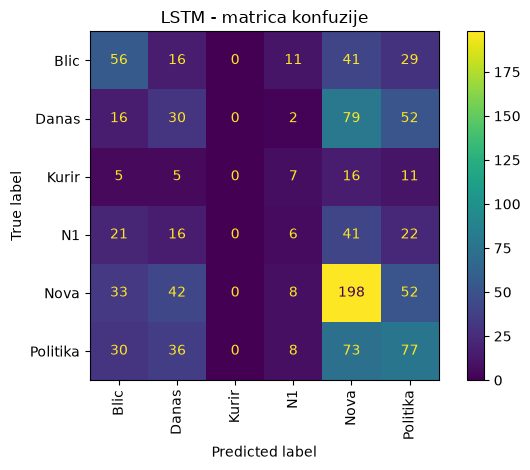

In [35]:
final_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = final_model(X_batch)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print("FINALNI LSTM MODEL")
print("Accuracy:", accuracy_score(all_labels, all_predictions))
print("Precision (macro):", precision_score(all_labels, all_predictions, average="macro", zero_division=0))
print("Recall (macro):", recall_score(all_labels, all_predictions, average="macro", zero_division=0))
print("F1-score (macro):", f1_score(all_labels, all_predictions, average="macro", zero_division=0))

print("\nClassification report:")
print(classification_report(
    all_labels,
    all_predictions,
    labels=np.arange(num_classes),
    target_names=class_names,
    zero_division=0
))

cm_lstm = confusion_matrix(all_labels, all_predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=class_names)
disp.plot(xticks_rotation=90)
plt.title("LSTM - matrica konfuzije")
plt.tight_layout()
plt.show()


Sada ćemo izračunati multiclass ROC-AUC. Pošto imamo više novina, koristi se **One-vs-Rest** pristup i prikazuje se macro AUC, odnosno prosečna AUC vrednost preko svih novina.


In [36]:
final_model.eval()

all_probabilities = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = final_model(X_batch)
        probabilities = torch.softmax(outputs, dim=1)

        all_probabilities.extend(probabilities.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

all_probabilities = np.array(all_probabilities)
all_labels = np.array(all_labels)
all_labels_bin = label_binarize(all_labels, classes=np.arange(num_classes))

lstm_macro_auc = roc_auc_score(
    all_labels_bin,
    all_probabilities,
    average="macro"
)

print(f"LSTM macro OvR AUC: {lstm_macro_auc:.4f}")


LSTM macro OvR AUC: 0.6105


Neuronska mreža ostvarila je značajno lošije performanse u odnosu na SVM modele, što se može povezati sa relativno malom količinom podataka za obučavanje. LSTM modeli zahtevaju veće skupove podataka kako bi uspešno naučili složene reprezentacije teksta, dok se SVM sa TF-IDF reprezentacijom pokazao znatno pogodnijim za dati skup podataka. Sa druge strane, TF-IDF reprezentacija u kombinaciji sa linearnim SVM-om veoma dobro odgovara ovom problemu, jer efikasno prepoznaje razlike u zastupljenosti reči i fraza između klasa. Rezultati zato pokazuju da složeniji model u ovom slučaju ne dovodi nužno do bolje klasifikacije.
